# Downloading Dataset

In [1]:
!gdown 1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7

Downloading...
From (original): https://drive.google.com/uc?id=1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7
From (redirected): https://drive.google.com/uc?id=1bbiPjv9eb7kTRMz0rvo4Vt2rkxV847e7&confirm=t&uuid=cac986cb-9007-4971-a2d0-23b71b512384
To: /content/finetune_sharegpt.jsonl
100% 194M/194M [00:02<00:00, 68.9MB/s]


In [6]:
!gdown 109g0JvBajIj_YgBDs5AufiD29nJViE1u

Downloading...
From (original): https://drive.google.com/uc?id=109g0JvBajIj_YgBDs5AufiD29nJViE1u
From (redirected): https://drive.google.com/uc?id=109g0JvBajIj_YgBDs5AufiD29nJViE1u&confirm=t&uuid=fadefe67-e15a-41f1-aa0d-7e95dbccab67
To: /content/dataset.zip
100% 808M/808M [00:15<00:00, 53.0MB/s]


In [9]:
!unzip -q dataset.zip -d dataset/

In [10]:
import os
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

In [101]:
image_folder_path = Path('/content/dataset')

In [102]:
image_classes = os.listdir(image_folder_path)
image_classes

['Rice Turgro', 'Rice Blast', 'Browon Spot', 'Leaf Scaled', 'Sheath Blight']

In [103]:
leaf_images = defaultdict(list)

for image_class in tqdm((image_classes)):
  for image in os.listdir(image_folder_path / image_class):
    leaf_images[image_class].append(Image.open(image_folder_path / image_class / image))

100%|██████████| 5/5 [00:00<00:00,  8.17it/s]


In [104]:
def get_random_image(given_image_class):
  image_class = None
  for folder_name in image_classes:
    if re.sub(r'[^A-Za-z]+', '', folder_name) == re.sub(r'[^A-Za-z]+', '', given_image_class):
      image_class = folder_name

  if image_class is None:
    return None
  return random.choice(leaf_images[image_class])

In [105]:
import time
import json
import re
import random

with open('finetune_sharegpt.jsonl') as f:
  data = [json.loads(sample) for sample in f.readlines()]

# Examples

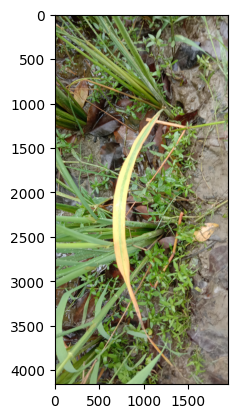

In [106]:
import matplotlib.pyplot as plt
plt.imshow(leaf_images['Rice Turgro'][0])

In [107]:
data[0]

{'id': 'rice_blast_001',
 'crop': 'rice',
 'symptom_text': 'আমার ধানের পাতায় ছোট ছোট বাদামী রঙের দাগ দেখা যাচ্ছে। প্রথমে মনে হয়েছিল পোকা লেগেছে, কিন্তু দাগগুলো বাড়ছে।',
 'image_path': None,
 'disease_label': 'Rice Blast (ধানের ব্লাস্ট)',
 'qa_flow': [{'role': 'assistant',
   'content': 'আপনার ধানের পাতায় কী ধরনের দাগ দেখা যাচ্ছে? দাগগুলো কি চোখের মতো গোল, নাকি অন্য কোনো আকারের? এবং কি দাগগুলো পুরো পাতায় ছড়িয়ে পড়ছে?'},
  {'role': 'user',
   'content': 'দাগগুলো প্রথমে ছোট ছিল, এখন অনেকটা চোখের মতো দেখাচ্ছে। চারপাশে হালকা বাদামী আর ভেতরে ধূসর। পাতাগুলো ধীরে ধীরে শুকিয়ে যাচ্ছে।'},
  {'role': 'assistant',
   'content': 'আপনি কি গাছের কাণ্ড বা শীষেও কোনো দাগ বা পরিবর্তন লক্ষ্য করেছেন? যেমন, কাণ্ডের গিঁটে বা শীষের গোড়ায় কোনো দাগ?'},
  {'role': 'user',
   'content': 'হ্যাঁ, শীষের গোড়ায় একটু কালচে দেখাচ্ছে। মনে হচ্ছে শীষ বেরোনোর সময় ভেঙে যেতে পারে।'}],
 'advice': 'আপনার ধানের জমিতে ব্লাস্ট রোগ দেখা দিয়েছে। দ্রুত Tricyclazole বা Propiconazole স্প্রে করুন। ইউরিয়ার ব্যবহার কমিয়ে দিন এবং জমিতে সব

In [108]:
SYSTEM_PROMPT = ''' You are an experienced agricultural expert. You will be provided with an image showing a plant or crop disease.
                    Your task is to interact with the user in a conversational manner to diagnose the problem. Ask relevant follow-up questions to clarify symptoms, crop type, growing conditions, and location if needed.
                    Based on the image and the user’s responses, identify the possible disease or issue, explain its causes, and provide clear, practical guidance on prevention and treatment.
                    All responses must be in Bengali, using simple, farmer-friendly language that is easy to understand and apply.
                '''

In [109]:
def fix_single_conversation(sample):
  merged = []
  last_role = None
  for s in sample:
    current_role = s['role']
    current_content = s['content'][0]['text']
    if last_role and last_role == current_role:
        merged[-1]['content'][0]['text'] += f'\n{current_content}'
    else:
        merged.append({'role': current_role, 'content': current_content})
        last_role = current_role
  return merged

In [147]:
def single_conv(sample):
    """Build a conversation from a sample, ensuring roles alternate properly"""

    # 1. Get the image
    image = get_random_image(sample['disease_label'])

    if image is None:
        return None

    # 2. Build ALL messages first (without worrying about consecutive roles)
    all_messages = []

    # Add system prompt + image as first USER message
    all_messages.append({
        'role': 'user',
        'content': [
            {'type': 'text', 'text': SYSTEM_PROMPT + '\n' + sample.get('symptom_text', '')},
            {'type': 'image', 'image': image}
        ]
    })

    # Add all QA flow messages
    for qa_entry in sample['qa_flow']:
        all_messages.append({
            'role': qa_entry['role'],
            'content': [{'type': 'text', 'text': qa_entry['content']}]
        })

    # Add final assistant message with advice
    all_messages.append({
        'role': 'assistant',
        'content': [{'type': 'text', 'text': sample['advice'] + '\n\nNote: ' + sample['notes']}]
    })

    # 3. NOW merge consecutive roles in a separate pass
    merged_messages = []

    for msg in all_messages:
        if not merged_messages:
            # First message - just add it
            merged_messages.append(msg)
        elif merged_messages[-1]['role'] == msg['role']:
            # SAME ROLE - Must merge the content
            last_msg = merged_messages[-1]

            # Assuming content is always a list of dicts, find and merge text parts
            last_text_item_found = False
            for item in reversed(last_msg['content']):
                if item['type'] == 'text':
                    item['text'] += '\n\n' + msg['content'][0]['text'] # Assuming incoming is also text
                    last_text_item_found = True
                    break

            if not last_text_item_found:
                # If last message had no text item (e.g., only image), add the new text
                last_msg['content'].append({'type': 'text', 'text': msg['content'][0]['text']})

            # If the new message also has other content types (like images), they would be appended here.
            # For this specific dataset, additional content after the first item is generally not expected
            # when merging text roles, but this could be extended if needed.

        else:
            # DIFFERENT ROLE - Just append as a new message
            merged_messages.append(msg)

    return merged_messages

# Build dataset with validation
dataset = []
failed_samples = []

for idx, sample in enumerate(tqdm(data)):
    try:
        conv = single_conv(sample)
        if conv is not None:
            # Validate before adding
            roles = [msg['role'] for msg in conv]

            # Check for consecutive same roles
            has_consecutive = False
            for i in range(len(roles) - 1):
                if roles[i] == roles[i + 1]:
                    has_consecutive = True
                    print(f"Sample {idx} has consecutive {roles[i]} roles. Roles: {roles}")
                    break

            if not has_consecutive:
                dataset.append(conv)
            else:
                failed_samples.append(idx)
        else:
            failed_samples.append(idx)
    except Exception as e:
        print(f"Error processing sample {idx}: {e}")
        failed_samples.append(idx)

print(f"\nSuccessfully processed: {len(dataset)} samples")
print(f"Failed samples: {len(failed_samples)}")

# Show a sample conversation structure
if dataset:
    print("\nSample conversation structure:")
    sample_conv = dataset[0]
    for i, msg in enumerate(sample_conv):
        content_types = [item['type'] for item in msg['content']]
        print(f"{i}. Role: {msg['role']}, Content types: {content_types}")

100%|██████████| 96311/96311 [00:02<00:00, 43683.11it/s]


Successfully processed: 48205 samples
Failed samples: 48106

Sample conversation structure:
0. Role: user, Content types: ['text', 'image']
1. Role: assistant, Content types: ['text']
2. Role: user, Content types: ['text']
3. Role: assistant, Content types: ['text']
4. Role: user, Content types: ['text']
5. Role: assistant, Content types: ['text']


# Data Structure

In [137]:
dataset = []

for sample in tqdm(data):
  dataset.append(single_conv(sample))


100%|██████████| 96311/96311 [00:03<00:00, 24979.31it/s]


In [138]:
len(dataset)

96311

In [131]:
def inconsistant(sample):
  roles = [sample['role'] for sample in sample]
  prev = None
  for r in roles:
    if prev == r:
      return True
    prev = r
  return False

In [132]:
filtered_dataset = []
for sample_conv in dataset:
  if not inconsistant(sample_conv):
    filtered_dataset.append(sample_conv)
dataset = filtered_dataset

In [133]:
dataset[5]

[{'role': 'user',
  'content': [{'type': 'text',
    'text': ' You are an experienced agricultural expert. You will be provided with an image showing a plant or crop disease.\n                    Your task is to interact with the user in a conversational manner to diagnose the problem. Ask relevant follow-up questions to clarify symptoms, crop type, growing conditions, and location if needed.\n                    Based on the image and the user’s responses, identify the possible disease or issue, explain its causes, and provide clear, practical guidance on prevention and treatment.\n                    All responses must be in Bengali, using simple, farmer-friendly language that is easy to understand and apply.\n                \nধানের পাতাগুলো দ্রুত হলুদ হয়ে যাচ্ছে এবং শুকিয়ে যাচ্ছে। মনে হচ্ছে যেন গাছ দুর্বল হয়ে পড়েছে।'},
   {'type': 'image',
    'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=3264x1536>}]},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'te

# Split

In [75]:
train_dataset = dataset[:int(len(dataset) * 0.8)]
test_dataset = dataset[int(len(dataset) * 0.8):]

# Gemma3_VL-4B

In [3]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.57.3
!pip install --no-deps trl==0.22.2

In [4]:
from unsloth import FastVisionModel
import torch

model, processor = FastVisionModel.from_pretrained(
    "unsloth/gemma-3-4b-pt",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.1.4: Fast Gemma3 patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.
Unsloth: Gemma3 does not support SDPA - switching to fast eager.


model.safetensors:   0%|          | 0.00/4.38G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

In [33]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
    target_modules = "all-linear",
)

In [34]:
from unsloth import get_chat_template

processor = get_chat_template(
    processor,
    "gemma-3"
)

# Fine Tuning

In [96]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    processing_class=processor.tokenizer,
    data_collator=UnslothVisionDataCollator(model, processor),
    args = SFTConfig(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,
        gradient_checkpointing = True,

        gradient_checkpointing_kwargs = {"use_reentrant": False},
        max_grad_norm = 0.3,
        warmup_ratio = 0.03,
        max_steps = 30,
        learning_rate = 2e-4,
        logging_steps = 1,
        save_strategy="steps",
        optim = "adamw_torch_fused",
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    )
)

Unsloth: Switching to float32 training since model cannot work with float16


In [148]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 57,503 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 38,497,792 of 4,338,577,264 (0.89% trained)


TemplateError: Conversation roles must alternate user/assistant/user/assistant/...

In [140]:
# Check a sample from your raw data
print("Sample raw data structure:")
print(json.dumps(data[0], indent=2, default=str))
print("\n" + "="*50 + "\n")

# Check what qa_flow looks like
if 'qa_flow' in data[0]:
    print("QA Flow structure:")
    for i, qa in enumerate(data[0]['qa_flow'][:3]):  # First 3 QA pairs
        print(f"QA {i}: {qa}")

Sample raw data structure:
{
  "id": "rice_blast_001",
  "crop": "rice",
  "symptom_text": "\u0986\u09ae\u09be\u09b0 \u09a7\u09be\u09a8\u09c7\u09b0 \u09aa\u09be\u09a4\u09be\u09df \u099b\u09cb\u099f \u099b\u09cb\u099f \u09ac\u09be\u09a6\u09be\u09ae\u09c0 \u09b0\u0999\u09c7\u09b0 \u09a6\u09be\u0997 \u09a6\u09c7\u0996\u09be \u09af\u09be\u099a\u09cd\u099b\u09c7\u0964 \u09aa\u09cd\u09b0\u09a5\u09ae\u09c7 \u09ae\u09a8\u09c7 \u09b9\u09df\u09c7\u099b\u09bf\u09b2 \u09aa\u09cb\u0995\u09be \u09b2\u09c7\u0997\u09c7\u099b\u09c7, \u0995\u09bf\u09a8\u09cd\u09a4\u09c1 \u09a6\u09be\u0997\u0997\u09c1\u09b2\u09cb \u09ac\u09be\u09dc\u099b\u09c7\u0964",
  "image_path": null,
  "disease_label": "Rice Blast (\u09a7\u09be\u09a8\u09c7\u09b0 \u09ac\u09cd\u09b2\u09be\u09b8\u09cd\u099f)",
  "qa_flow": [
    {
      "role": "assistant",
      "content": "\u0986\u09aa\u09a8\u09be\u09b0 \u09a7\u09be\u09a8\u09c7\u09b0 \u09aa\u09be\u09a4\u09be\u09df \u0995\u09c0 \u09a7\u09b0\u09a8\u09c7\u09b0 \u09a6\u09be\u0997 \u09a6

# Loss Curve

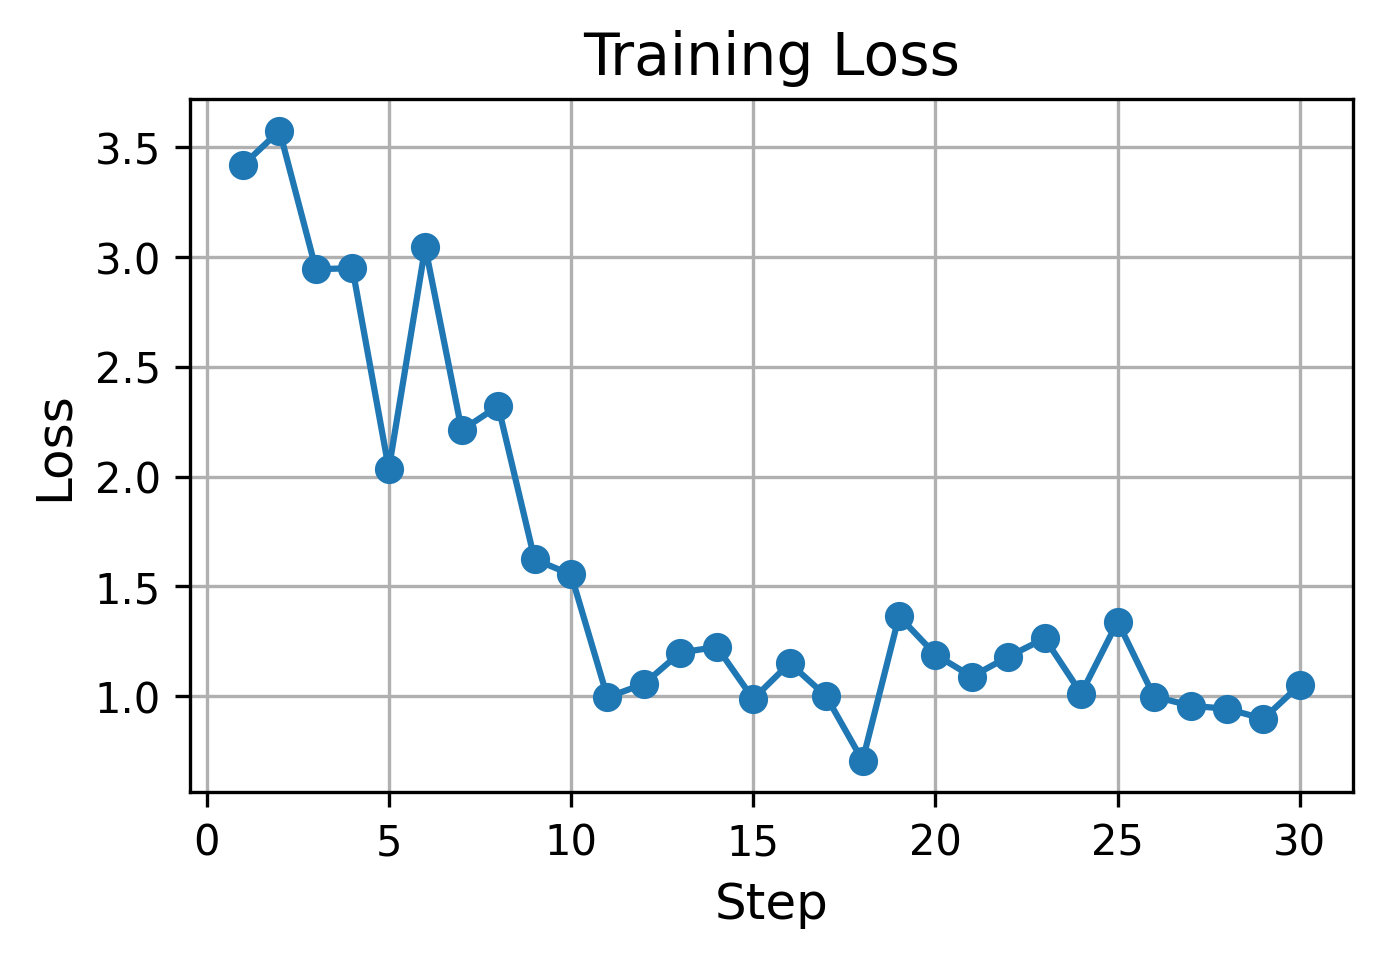

In [ ]:
import json
import matplotlib.pyplot as plt

file_path = "/content/outputs/checkpoint-30/trainer_state.json"

with open(file_path, 'r') as f:
    trainer_state = json.load(f)

log_history = trainer_state.get("log_history", [])

steps = [entry["step"] for entry in log_history]
losses = [entry["loss"] for entry in log_history]

plt.figure(figsize=(5, 3), dpi=300)
plt.plot(steps, losses, marker='o')
plt.title('Training Loss', fontsize=14)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.grid(True)
plt.show()

# Save Model

In [ ]:
# !rm -rf llama.cpp
# !git clone --recursive https://github.com/ggerganov/llama.cpp
# !cd llama.cpp && mkdir build && cd build && cmake .. && cmake --build .
# !cp llama.cpp/convert_hf_to_gguf.py llama.cpp/unsloth_convert_hf_to_gguf.py


In [ ]:
# model.save_pretrained_gguf("lora_model", tokenizer, quantization_method = "q4_k_m")

# Evaluation

In [ ]:
def generate_report(image):
    if image.mode != 'RGB':
        image = image.convert('RGB')

    instruction = f'Please provide a brief and accurate summary of this image, plots, and graphs. Do not say anything else. Just a few words about the chart about what the chart about and the numbers. Respond in Formal Bengali and describe all the numbers'

    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": instruction}
        ]}
    ]

    input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(
        image,
        input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=1000,
        use_cache=True,
        temperature=0.5,
        min_p=0.1
    )

    report_text = processor.batch_decode(outputs, skip_special_tokens=True)[0].split("model\n")[-1]
    return report_text.replace(instruction, "").strip()

In [ ]:
from tqdm import tqdm

predictions = []
indices = len(test_dataset)

for i in tqdm(range(indices)):
    image = images[i]
    report = generate_report(image)
    predictions.append(report)

print("Processing complete.")

100%|██████████| 101/101 [1:26:08<00:00, 51.17s/it]

Processing complete.


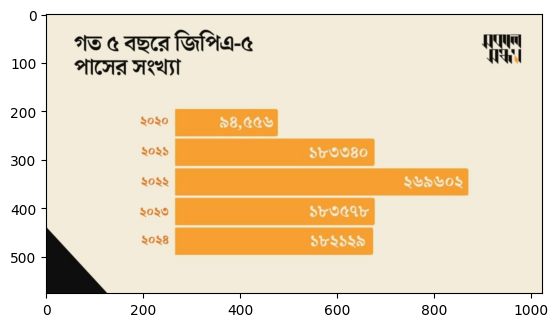

'গত ৬ বছরে জিগিপিতে পাসের সংখ্যা (২০২০: ১.৫৬,২০২১: ১.৩০,২০২২: ১.৬৯,২০২৩: ১.৫৩,২০২৪: ১.৫৩,২০২৫: ১.১১)।'

In [ ]:
plt.imshow(images[10])
plt.show()
generate_report(images[10])

In [ ]:
!pip install rouge_score jiwer -q
class BengaliTokenizer:
    def tokenize(self, text):
        return [r[0].split()[0] for r in  ref.split()]

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.2 MB/s eta 0:00:00


In [ ]:
test_dataset = [data['messages'][-1]['content'][-1]['text'] for data in test_dataset]

In [ ]:
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from collections import Counter
import math
import nltk
nltk.download('wordnet')
from rouge_score import rouge_scorer
from jiwer import wer
import math

bleu_scores = []
meteor_scores = []
rouge1_fmeasures = []
rouge2_fmeasures = []
rougel_fmeasures = []
wer_scores = []

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True, tokenizer=BengaliTokenizer())

for pred, ref in zip(predictions, test_dataset):

    pred_tokens = BengaliTokenizer().tokenize(pred)
    ref_tokens = BengaliTokenizer().tokenize(ref)

    # BLEU Score
    bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=SmoothingFunction().method1)
    bleu_scores.append(bleu)

    # METEOR Score
    meteor = meteor_score([ref_tokens], pred_tokens)
    meteor_scores.append(meteor)

    # ROUGE Scores
    scores = scorer.score(ref, pred)
    rouge1_fmeasures.append(scores['rouge1'].fmeasure)
    rouge2_fmeasures.append(scores['rouge2'].fmeasure)
    rougel_fmeasures.append(scores['rougeL'].fmeasure)

    # WER Score
    wer_value = wer(ref, pred)
    wer_scores.append(wer_value)

print("BLEU:", np.mean(bleu_scores))
print("METEOR:", np.mean(meteor_scores))
print("ROUGE-1 F-measure:", np.mean(rouge1_fmeasures))
print("ROUGE-2 F-measure:", np.mean(rouge2_fmeasures))
print("ROUGE-L F-measure:", np.mean(rougel_fmeasures))
print("WER:", np.mean(wer_scores))

def calculate_ngram_perplexity(corpus, n=2):
    tokens = " ".join(corpus).split()
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    ngram_counts = Counter(ngrams)
    context_counts = Counter([ng[:-1] for ng in ngrams])

    log_prob = 0
    N = len(ngrams)

    if N == 0: return float('inf')

    for ng in ngrams:
        context = ng[:-1]
        if context_counts[context] == 0:
            prob = 0
        else:
            prob = ngram_counts[ng] / context_counts[context]

        if prob > 0:
            log_prob += math.log(prob)
        else:
            log_prob += math.log(1e-10)

    return math.exp(-log_prob / N)

print("Perplexity:", calculate_ngram_perplexity(predictions, n=2))


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


BLEU: 1.0
METEOR: 0.9998795617120094
ROUGE-1 F-measure: 1.0
ROUGE-2 F-measure: 1.0
ROUGE-L F-measure: 1.0
WER: 3.5789023649484024
Perplexity: 2.900183401179216
